#  Students Exam Scores: Extended Dataset data analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.style as style
import warnings
warnings.filterwarnings("ignore")
custom_palette = sns.color_palette('viridis', 3)
sns.set_palette(custom_palette)

# PART 1 - Choose a dataset

## Students Exam Scores: Extended Dataset
#### This dataset includes scores from three test scores of students at a (fictional) public school and a variety of personal and socio-economic factors that may have interaction effects upon them.

In [16]:
Students_Exam_Scores_df = pd.read_csv('Expanded_data_with_more_features.csv')

In [17]:
display(Students_Exam_Scores_df.head())
display(Students_Exam_Scores_df.describe())
display(Students_Exam_Scores_df.describe(include=['O']))
Students_Exam_Scores_df.info()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,TransportMeans,WklyStudyHours
count,30641,28801,28796,30641,28811,29451,30010,29737,27507,29686
unique,2,5,6,2,2,4,3,2,2,3
top,female,group C,some college,standard,none,married,sometimes,yes,school_bus,5 - 10
freq,15424,9212,6633,19905,18856,16844,15213,19082,16145,16246


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


- Our Data-set includes 30,641 records and has 14 features
- There are 4 numeric variables and 10 categorical variables. 
- We can see that *EthnicGroup*, *ParentEduc*, *TestPrep*,*ParentMaritalStatus*, *PracticeSport*, *IsFirstChild*, *NrSiblings*, *TransportMeans*, *WklyStudyHours* have missing values.

In [6]:
# Add a 'Mean' column
Students_Exam_Scores_df['Mean'] = Students_Exam_Scores_df[['MathScore', 'ReadingScore', 'WritingScore']].mean(axis=1)
display(Students_Exam_Scores_df.head())

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore,Mean
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74,72.000000
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88,82.333333
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91,90.333333
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42,47.666667
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75,76.333333


# PART 2 - Exploratory data analysis

1. Plots illustrating distribution for a single variable of the following 5 variables:

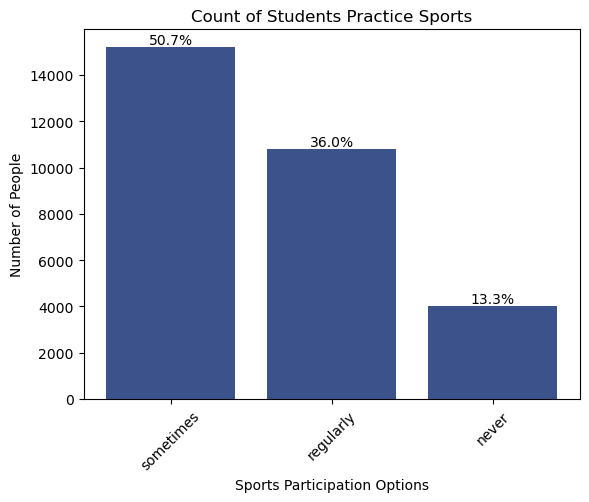

In [6]:
# Drop rows with missing values in the 'PracticeSport' column
Students_Exam_Scores_df_cleaned = Students_Exam_Scores_df.dropna(subset=['PracticeSport'])

# Count the occurrences of each option after removing missing values
sports_count = Students_Exam_Scores_df_cleaned['PracticeSport'].value_counts()

# Calculate the total number of people for percentage calculation
total_people = sports_count.sum()

# Create a bar chart
plt.bar(sports_count.index, sports_count.values)

# Add percentage on top of each bar
for i, count in enumerate(sports_count.values):
    percentage = (count / total_people) * 100
    plt.text(i, count + 5, f'{percentage:.1f}%', ha='center', va='bottom')

plt.xlabel('Sports Participation Options')
plt.ylabel('Number of People')
plt.title('Count of Students Practice Sports')
plt.xticks(rotation=45)

plt.show()


Some of the cells of the 'PracticeSport' variable are empty(null value), this amount is negligible as shown here:

In [7]:
# Count the number of empty cells (missing values) in the 'PracticeSport' column
empty_cells_count = Students_Exam_Scores_df['PracticeSport'].isnull().sum()
print("Absolut number of Nulls in the 'PracticeSport' column is: ",empty_cells_count)

# Calculate the total number of cells in the 'PracticeSport' column
total_cells = Students_Exam_Scores_df['PracticeSport'].shape[0]

# Calculate the percentage of nulls
percentage_nulls = (empty_cells_count / total_cells) * 100

print("Percentage of nulls in 'PracticeSport' column:", percentage_nulls)

Absolut number of Nulls in the 'PracticeSport' column is:  631
Percentage of nulls in 'PracticeSport' column: 2.0593322672236547


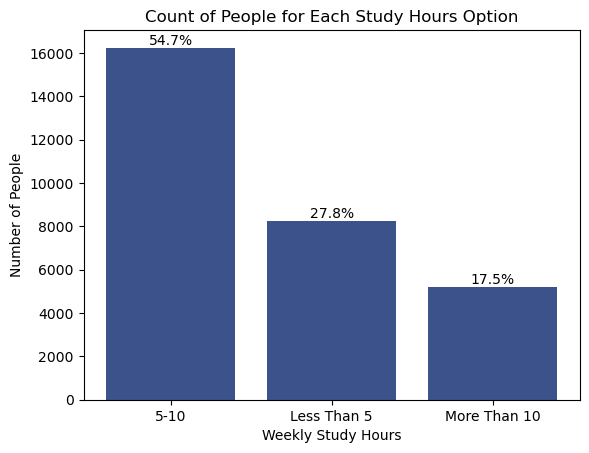

In [8]:
# Filter out missing values (NaN) in the 'WklyStudyHours' column
non_zero_study_hours = Students_Exam_Scores_df['WklyStudyHours'].dropna()

# Count the occurrences of each option
study_hours_count = non_zero_study_hours.value_counts()

# Calculate the total number of people for percentage calculation
total_people = study_hours_count.sum()

# Create a dictionary to map the original values to the desired labels
custom_labels = {'> 10': 'More Than 10', '5 - 10': '5-10', '< 5': 'Less Than 5'}

# Replace the values in study_hours_count with the custom labels
study_hours_count.index = study_hours_count.index.map(custom_labels)

# Create a bar chart
plt.bar(study_hours_count.index, study_hours_count.values)

# Add percentage at the base of each bar
for i, count in enumerate(study_hours_count.values):
    percentage = (count / total_people) * 100
    plt.text(i, count, f'{percentage:.1f}%', ha='center', va='bottom')

# Customize the plot
plt.xlabel('Weekly Study Hours')
plt.ylabel('Number of People')
plt.title('Count of People for Each Study Hours Option')

# Show the plot
plt.show()

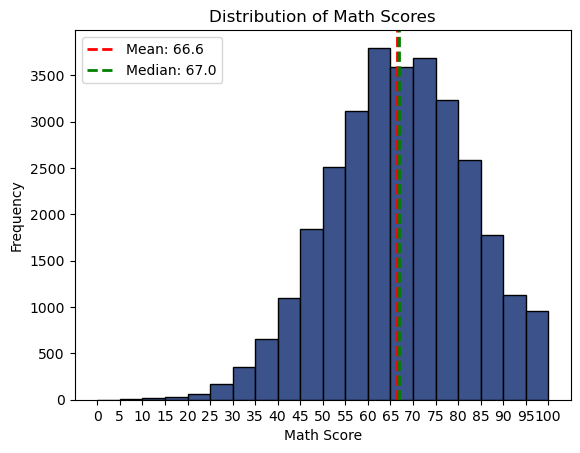

In [9]:
# Create a histogram with bins incrementing by 5
plt.hist(Students_Exam_Scores_df['MathScore'], bins=range(0, 101, 5), edgecolor='black')

# Calculate mean and median of Math scores
mean_score = Students_Exam_Scores_df['MathScore'].mean()
median_score = Students_Exam_Scores_df['MathScore'].median()

# Add mean and median as vertical lines on the histogram
plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_score:.1f}')
plt.axvline(median_score, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_score:.1f}')

# Customize the plot
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.title('Distribution of Math Scores')
plt.legend()

# Set x-axis ticks to show grades in increments of 5
plt.xticks(range(0, 101, 5))

# Show the plot
plt.show()

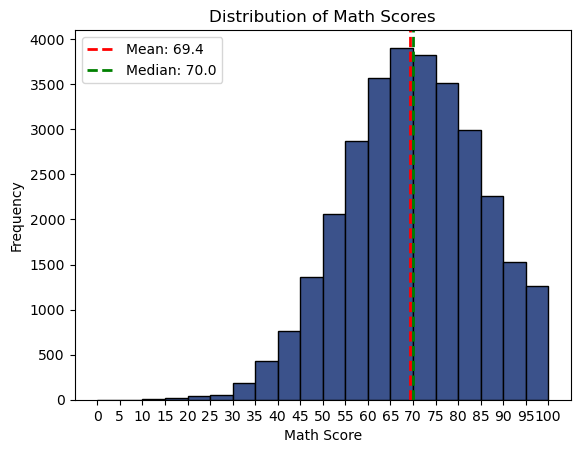

In [10]:
# Create a histogram with bins incrementing by 5
plt.hist(Students_Exam_Scores_df['ReadingScore'], bins=range(0, 101, 5), edgecolor='black')

# Calculate mean and median of Math scores
mean_score = Students_Exam_Scores_df['ReadingScore'].mean()
median_score = Students_Exam_Scores_df['ReadingScore'].median()

# Add mean and median as vertical lines on the histogram
plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_score:.1f}')
plt.axvline(median_score, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_score:.1f}')

# Customize the plot
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.title('Distribution of Math Scores')
plt.legend()

# Set x-axis ticks to show grades in increments of 5
plt.xticks(range(0, 101, 5))

# Show the plot
plt.show()

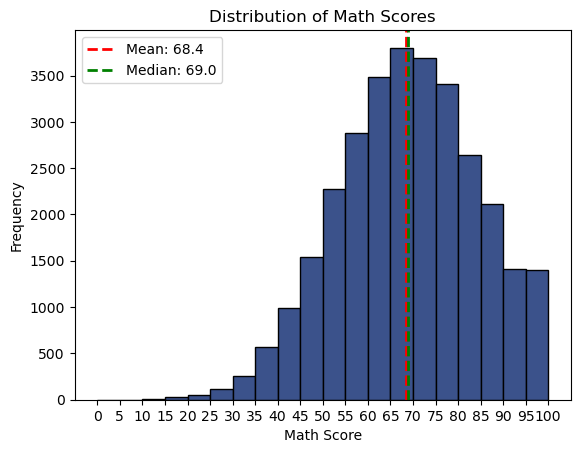

In [11]:
# Create a histogram with bins incrementing by 5
plt.hist(Students_Exam_Scores_df['WritingScore'], bins=range(0, 101, 5), edgecolor='black')

# Calculate mean and median of Math scores
mean_score = Students_Exam_Scores_df['WritingScore'].mean()
median_score = Students_Exam_Scores_df['WritingScore'].median()

# Add mean and median as vertical lines on the histogram
plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_score:.1f}')
plt.axvline(median_score, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_score:.1f}')

# Customize the plot
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.title('Distribution of Math Scores')
plt.legend()

# Set x-axis ticks to show grades in increments of 5
plt.xticks(range(0, 101, 5))

# Show the plot
plt.show()

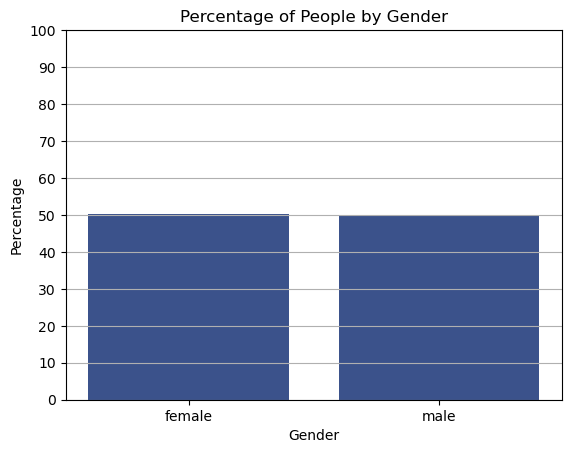

In [12]:
gender_counts = Students_Exam_Scores_df['Gender'].value_counts()
total_people = gender_counts.sum()

percentage_values = (gender_counts / total_people) * 100

plt.bar(percentage_values.index, percentage_values.values)
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.title('Percentage of People by Gender')
plt.ylim(0, 100)  # Set y-axis limit to 0-100 for percentage
plt.xticks(percentage_values.index, labels=percentage_values.index)  # Set x-axis ticks to gender categories
plt.yticks(range(0, 101, 10))  # Set y-axis ticks for percentage
plt.gca().yaxis.grid(True)  # Add horizontal grid lines
plt.show()

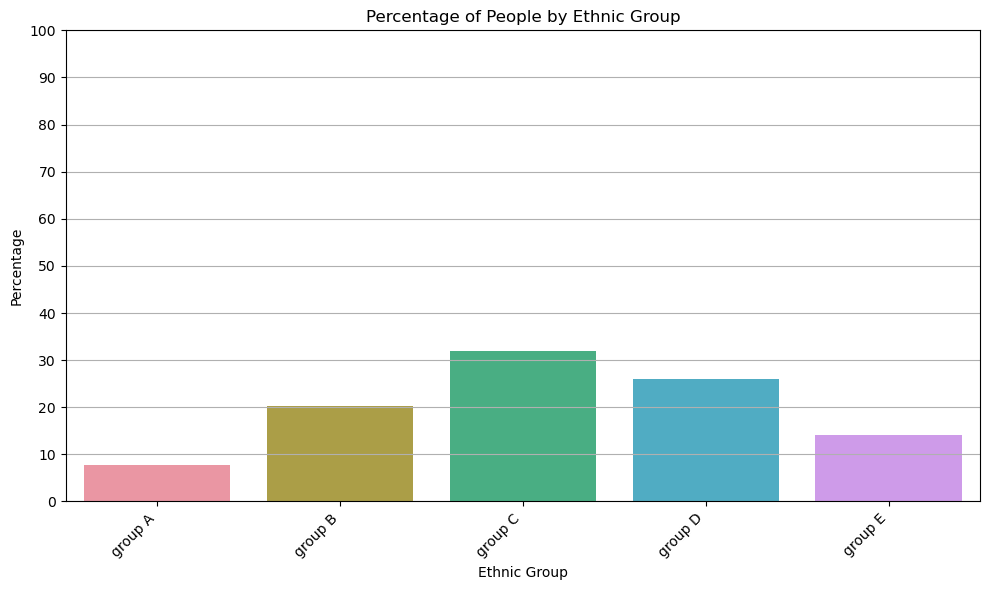

In [13]:
# Count the occurrences of each EthnicGroup
ethnic_group_counts = Students_Exam_Scores_df['EthnicGroup'].value_counts()

# Calculate the total number of people
total_people = ethnic_group_counts.sum()

# Calculate the percentage for each EthnicGroup
percentage_values = (ethnic_group_counts / total_people) * 100

# Sort the percentage values by the index (EthnicGroup names in alphabetical order)
percentage_values_sorted = percentage_values.sort_index()

# Create a bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=percentage_values_sorted.index, y=percentage_values_sorted.values)

plt.xlabel('Ethnic Group')
plt.ylabel('Percentage')
plt.title('Percentage of People by Ethnic Group')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.yticks(range(0, 101, 10))
plt.gca().yaxis.grid(True)
plt.tight_layout()
plt.show()

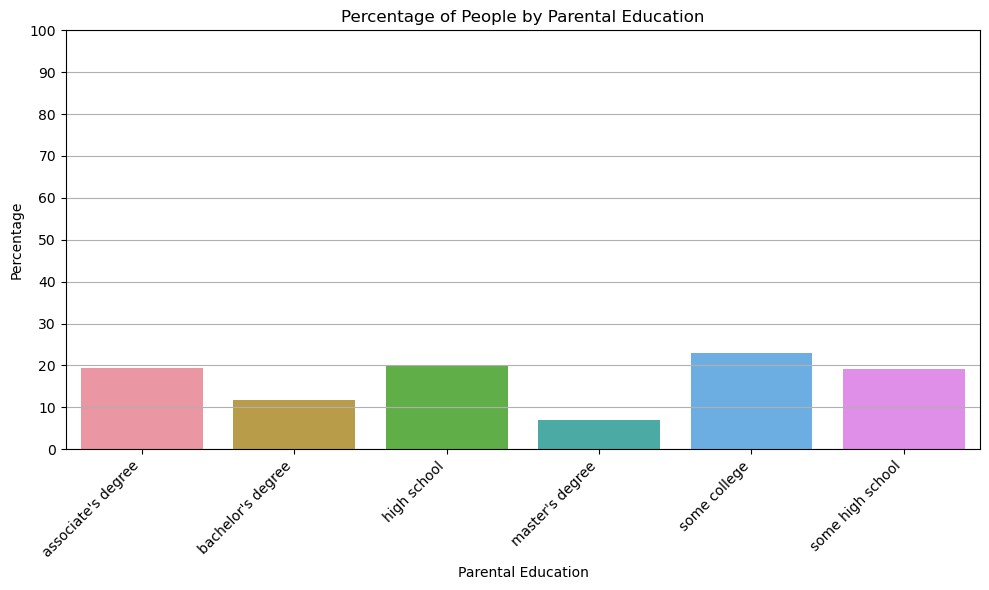

In [14]:
# Count the occurrences of each ParentEduc category
parent_educ_counts = Students_Exam_Scores_df['ParentEduc'].value_counts()

# Calculate the total number of people
total_people = parent_educ_counts.sum()

# Calculate the percentage for each ParentEduc category
percentage_values = (parent_educ_counts / total_people) * 100

# Sort the percentage values by the index (ParentEduc categories in alphabetical order)
percentage_values_sorted = percentage_values.sort_index()

# Create a bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=percentage_values_sorted.index, y=percentage_values_sorted.values)

plt.xlabel('Parental Education')
plt.ylabel('Percentage')
plt.title('Percentage of People by Parental Education')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.yticks(range(0, 101, 10))
plt.gca().yaxis.grid(True)
plt.tight_layout()
plt.show()

2. Plots illustrating distribution for a bivariate relationships:

Correlation between categorical and numerical variables in the following graph plots:
the following plots show the relation between categorical and numerical variables, therefore we cannot use Pearson correlation. We chose to use mean and median of the bivariate relation to understand if there is any trend or dependency between each two variables.

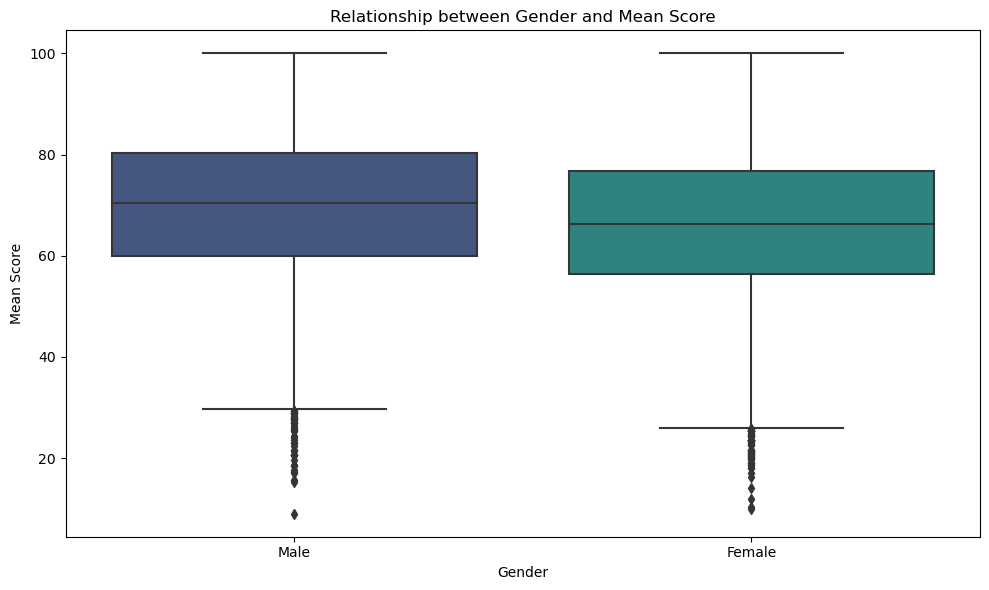

In [15]:
# Create a box plot using Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Mean', data=Students_Exam_Scores_df)

plt.xlabel('Gender')
plt.ylabel('Mean Score')
plt.title('Relationship between Gender and Mean Score')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.tight_layout()
plt.show()

Explanation:
The first thing we observe, there is a minor difference between the median of Mean score across Genders.
The second thing to observed is that the Male category has a higher median Mean score.
Given the plot we can infer weak positive correlation between student Gender and Mean score (males have higher median of Mean score).

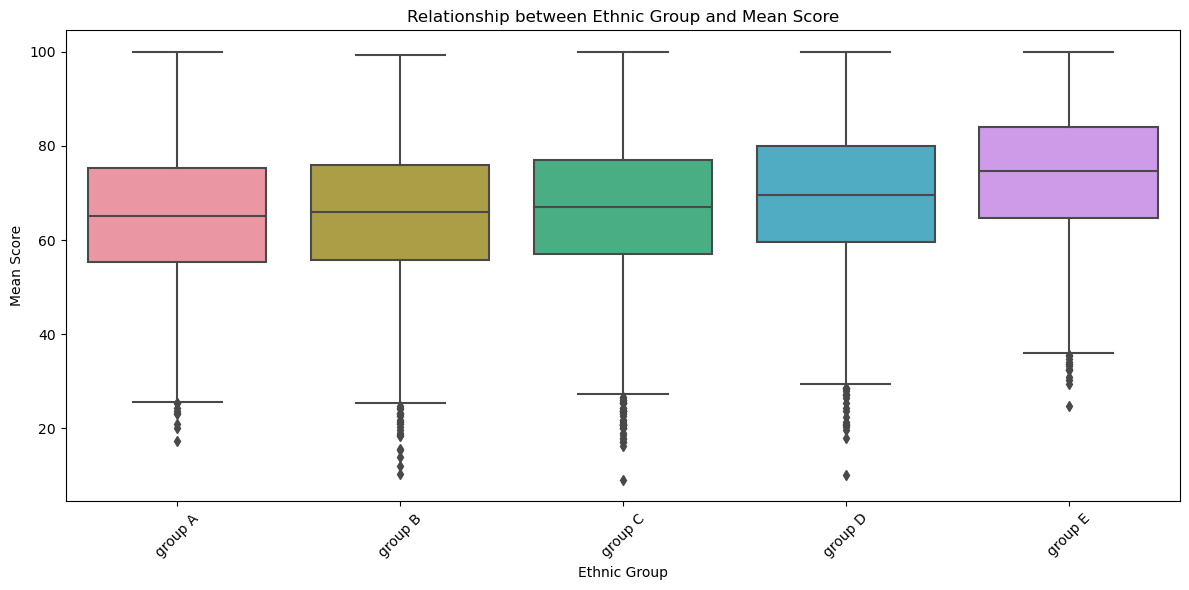

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='EthnicGroup', y='Mean', data=Students_Exam_Scores_df, order=['group A', 'group B', 'group C', 'group D', 'group E'])

plt.xlabel('Ethnic Group')
plt.ylabel('Mean Score')
plt.title('Relationship between Ethnic Group and Mean Score')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Explanation:<br>
We can observe that there is a difference in medians of Mean score between different Ethnic groups, the most obvious one is between group A and E.<br>
We can say that it seems that there is a weak positive correlation between group E and high median Mean score.<br>
It seems that even though that there is no internal order between the Ethnic groups, once we check the achievements of the students by group order appear A - lowest Mean score to E - highest Mean score.

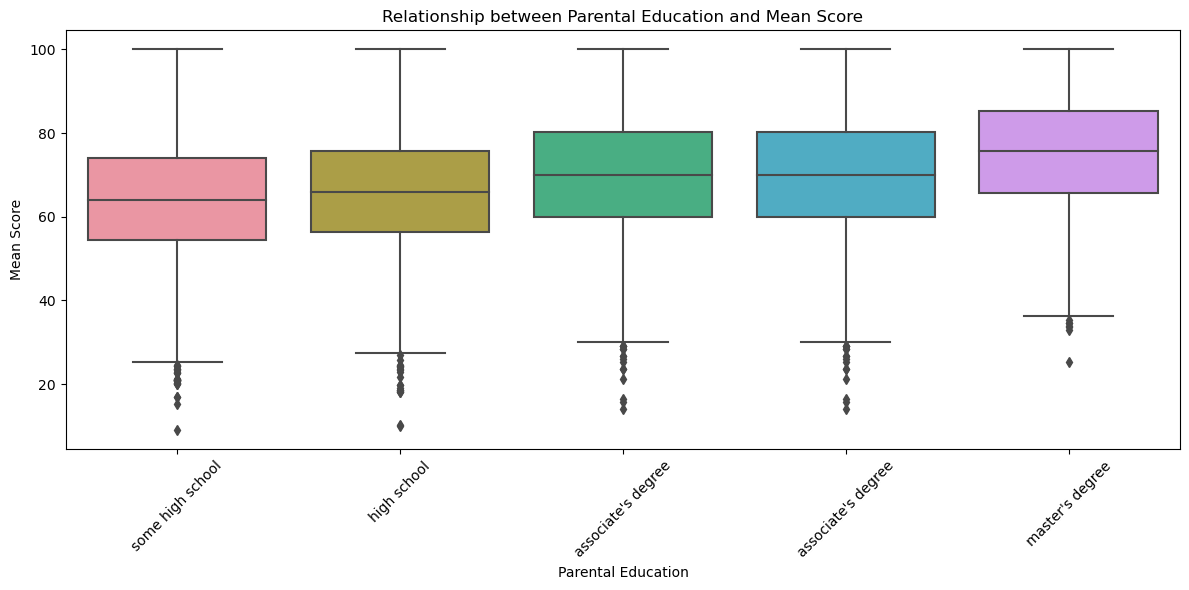

In [17]:
# Create a box plot using Seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(x='ParentEduc', y='Mean', data=Students_Exam_Scores_df,  order=["some high school", "high school", "associate's degree", "associate's degree", "master's degree"])

plt.xlabel('Parental Education')
plt.ylabel('Mean Score')
plt.title('Relationship between Parental Education and Mean Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Explanation:<br>
We can observe that there is a difference in medians of Mean score between different Parental Education, the most obvious one is between 'some high school' and 'masters degree'.<br>
When observe an order in the Mean scores that aligns with the order of Parental Education levels from "Some high school" to "Masters degree," <br>
It indicates that there might be a correlation between the level of parental education and student achievement.

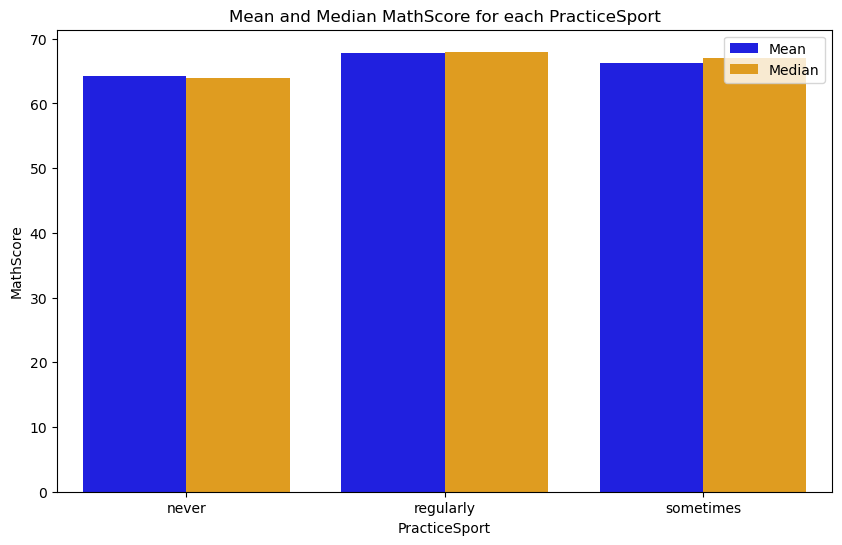

In [18]:
# Filter out missing values (NaN) in the 'PracticeSport' and 'MathScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'MathScore'])

# Calculate the mean MathScore for each category in PracticeSport
mean_scores = valid_data.groupby('PracticeSport')['MathScore'].mean().reset_index()

# Calculate the median MathScore for each category in PracticeSport
median_scores = valid_data.groupby('PracticeSport')['MathScore'].median().reset_index()

# Combine mean and median DataFrames into a single DataFrame
merged_scores = pd.concat([mean_scores.assign(Type='Mean'), median_scores.assign(Type='Median')])

# Create the unified bar plot to show mean and median for each category in PracticeSport
plt.figure(figsize=(10, 6))

# Plot the mean and median MathScores as bars using the 'hue' parameter to distinguish them
sns.barplot(x='PracticeSport', y='MathScore', hue='Type', data=merged_scores, palette=['blue', 'orange'])

# Customize the plot
plt.xlabel('PracticeSport')
plt.ylabel('MathScore')
plt.title('Mean and Median MathScore for each PracticeSport')
plt.legend()

# Show the plot
plt.show()

In [19]:
# Filter out missing values (NaN) in the 'PracticeSport' and 'MathScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'MathScore'])

# Calculate the mean MathScore for each category in PracticeSport
mean_scores = valid_data.groupby('PracticeSport')['MathScore'].mean()

# Calculate the median MathScore for each category in PracticeSport
median_scores = valid_data.groupby('PracticeSport')['MathScore'].median()

print("Mean MathScore for each category in PracticeSport:")
print(mean_scores)

print("\nMedian MathScore for each category in PracticeSport:")
print(median_scores)


Mean MathScore for each category in PracticeSport:
PracticeSport
never        64.171079
regularly    67.839155
sometimes    66.274831
Name: MathScore, dtype: float64

Median MathScore for each category in PracticeSport:
PracticeSport
never        64.0
regularly    68.0
sometimes    67.0
Name: MathScore, dtype: float64


Explanation:
The first thing we observe, there is a minor difference between the mean and median (we can infer the absent of extreme values) of Math score across all sports rates.
The second thing we observes, there is a minor difference between the values of mean and median of each group, Therefor the group has similar result of Math score.
Given the plot we cannot infer any correlation between PracticeSport tendency and MathScore of students.

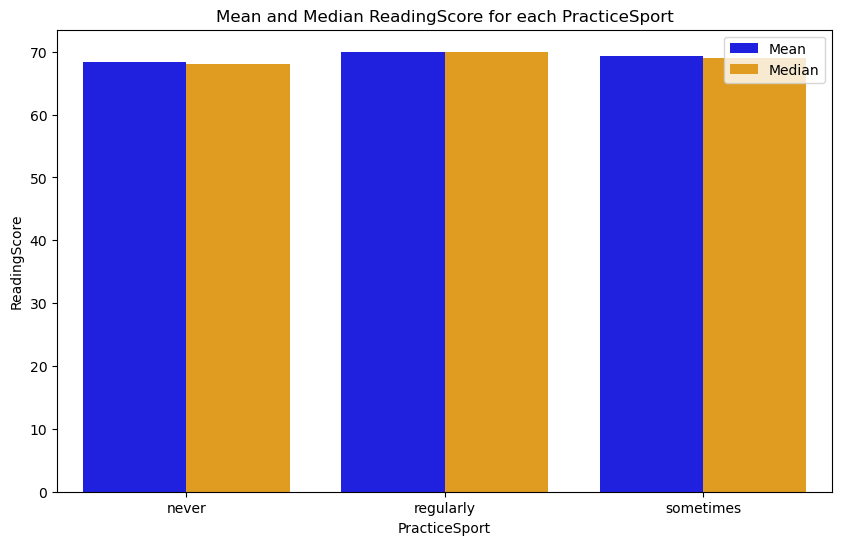

In [20]:
# Filter out missing values (NaN) in the 'PracticeSport' and 'ReadingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'ReadingScore'])

# Calculate the mean ReadingScore for each category in PracticeSport
mean_scores = valid_data.groupby('PracticeSport')['ReadingScore'].mean().reset_index()

# Calculate the median ReadingScore for each category in PracticeSport
median_scores = valid_data.groupby('PracticeSport')['ReadingScore'].median().reset_index()

# Combine mean and median DataFrames into a single DataFrame
merged_scores = pd.concat([mean_scores.assign(Type='Mean'), median_scores.assign(Type='Median')])

# Create the unified bar plot to show mean and median for each category in PracticeSport
plt.figure(figsize=(10, 6))

# Plot the mean and median ReadingScores as bars using the 'hue' parameter to distinguish them
sns.barplot(x='PracticeSport', y='ReadingScore', hue='Type', data=merged_scores, palette=['blue', 'orange'])

# Customize the plot
plt.xlabel('PracticeSport')
plt.ylabel('ReadingScore')
plt.title('Mean and Median ReadingScore for each PracticeSport')
plt.legend()

# Show the plot
plt.show()

In [21]:
# Filter out missing values (NaN) in the 'PracticeSport' and 'ReadingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'ReadingScore'])

# Calculate the mean ReadingScore for each category in PracticeSport
mean_scores = valid_data.groupby('PracticeSport')['ReadingScore'].mean()

# Calculate the median ReadingScore for each category in PracticeSport
median_scores = valid_data.groupby('PracticeSport')['ReadingScore'].median()

print("Mean ReadingScore for each category in PracticeSport:")
print(mean_scores)

print("\nMedian ReadingScore for each category in PracticeSport:")
print(median_scores)

Mean ReadingScore for each category in PracticeSport:
PracticeSport
never        68.337662
regularly    69.943019
sometimes    69.241307
Name: ReadingScore, dtype: float64

Median ReadingScore for each category in PracticeSport:
PracticeSport
never        68.0
regularly    70.0
sometimes    69.0
Name: ReadingScore, dtype: float64


Explanation:
The first thing we observe, there is a minor difference between the mean and median (we can infer the absent of extreme values) of Reading score across all sports rates.
The second thing we observes, there is a minor difference between the values of mean and median of each group, Therefor the group has similar result of Reading score.
Given the plot we cannot infer any correlation between PracticeSport tendency and ReadingScore of students.

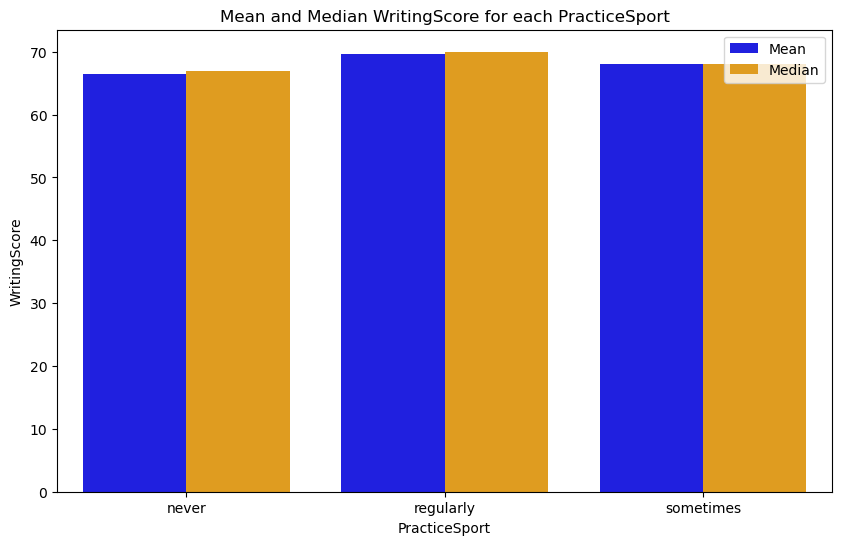

In [22]:
# Filter out missing values (NaN) in the 'PracticeSport' and 'WritingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'WritingScore'])

# Calculate the mean MathScore for each category in PracticeSport
mean_scores = valid_data.groupby('PracticeSport')['WritingScore'].mean().reset_index()

# Calculate the median MathScore for each category in PracticeSport
median_scores = valid_data.groupby('PracticeSport')['WritingScore'].median().reset_index()

# Combine mean and median DataFrames into a single DataFrame
merged_scores = pd.concat([mean_scores.assign(Type='Mean'), median_scores.assign(Type='Median')])

# Create the unified bar plot to show mean and median for each category in PracticeSport
plt.figure(figsize=(10, 6))

# Plot the mean and median WritingScore as bars using the 'hue' parameter to distinguish them
sns.barplot(x='PracticeSport', y='WritingScore', hue='Type', data=merged_scores, palette=['blue', 'orange'])

# Customize the plot
plt.xlabel('PracticeSport')
plt.ylabel('WritingScore')
plt.title('Mean and Median WritingScore for each PracticeSport')
plt.legend()

# Show the plot
plt.show()

In [23]:
# Filter out missing values (NaN) in the 'WritingScore' and 'ReadingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'WritingScore'])

# Calculate the mean ReadingScore for each category in WritingScore
mean_scores = valid_data.groupby('PracticeSport')['WritingScore'].mean()

# Calculate the median ReadingScore for each category in WritingScore
median_scores = valid_data.groupby('PracticeSport')['WritingScore'].median()

print("Mean WritingScore for each category in PracticeSport:")
print(mean_scores)

print("\nMedian WritingScore for each category in PracticeSport:")
print(median_scores)

Mean WritingScore for each category in PracticeSport:
PracticeSport
never        66.522727
regularly    69.604003
sometimes    68.072438
Name: WritingScore, dtype: float64

Median WritingScore for each category in PracticeSport:
PracticeSport
never        67.0
regularly    70.0
sometimes    68.0
Name: WritingScore, dtype: float64


Explanation:
The first thing we observe, there is a minor difference between the mean and median (we can infer the absent of extreme values) of Writing score across all sports rates.
The second thing we observes, there is a minor difference between the values of mean and median of each group, Therefor the group has similar result of Writing score.
Given the plot we cannot infer any correlation between PracticeSport tendency and WritingScore of students.

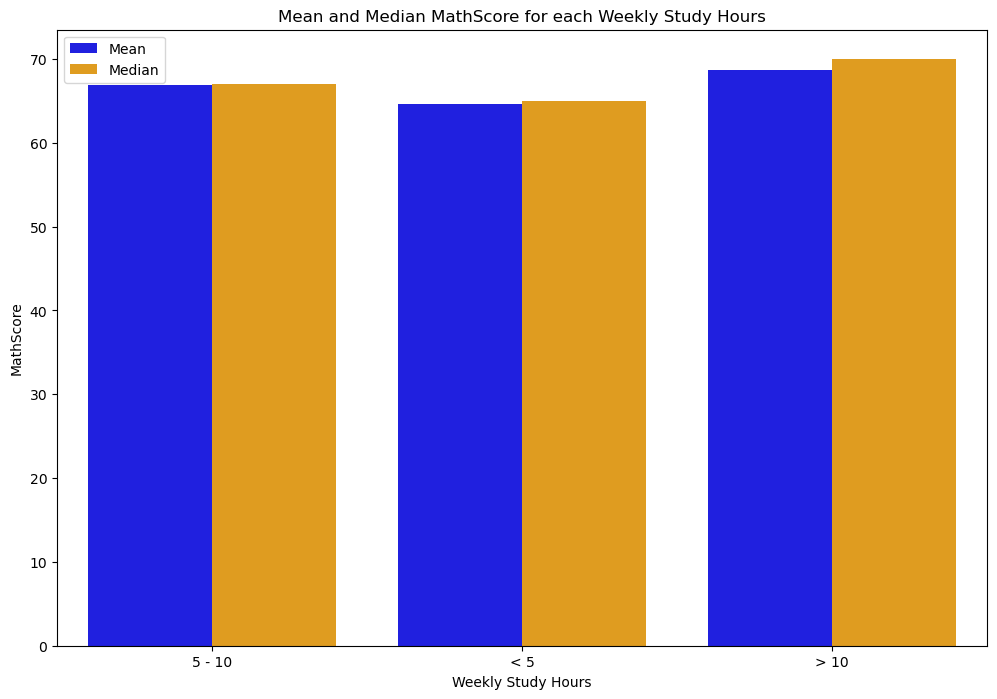

In [24]:
# Filter out missing values (NaN) in the 'WklyStudyHours' and 'MathScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['WklyStudyHours', 'MathScore'])

# Calculate the mean MathScore for each category in WklyStudyHours
mean_scores = valid_data.groupby('WklyStudyHours')['MathScore'].mean().reset_index()

# Calculate the median MathScore for each category in WklyStudyHours
median_scores = valid_data.groupby('WklyStudyHours')['MathScore'].median().reset_index()

# Combine mean and median DataFrames into a single DataFrame
merged_scores = pd.concat([mean_scores.assign(Type='Mean'), median_scores.assign(Type='Median')])

# Create the unified bar plot to show mean and median for each category in WklyStudyHours
plt.figure(figsize=(12, 8))

# Plot the mean and median MathScores as bars using the 'hue' parameter to distinguish them
sns.barplot(x='WklyStudyHours', y='MathScore', hue='Type', data=merged_scores, palette=['blue', 'orange'])

# Customize the plot
plt.xlabel('Weekly Study Hours')
plt.ylabel('MathScore')
plt.title('Mean and Median MathScore for each Weekly Study Hours')
plt.legend()

# Show the plot
plt.show()

Explanation:
The first thing we observe, there is a minor difference between the mean and median (we can infer the absent of extreme values) of Math score across all Weekly Study Hours.
The second thing we observes, there is a minor difference between the values of mean and median of each group, Therefor the group has similar result of Math score.
Given the plot we cannot infer any correlation between Weekly Study Hours and MathScore of students.

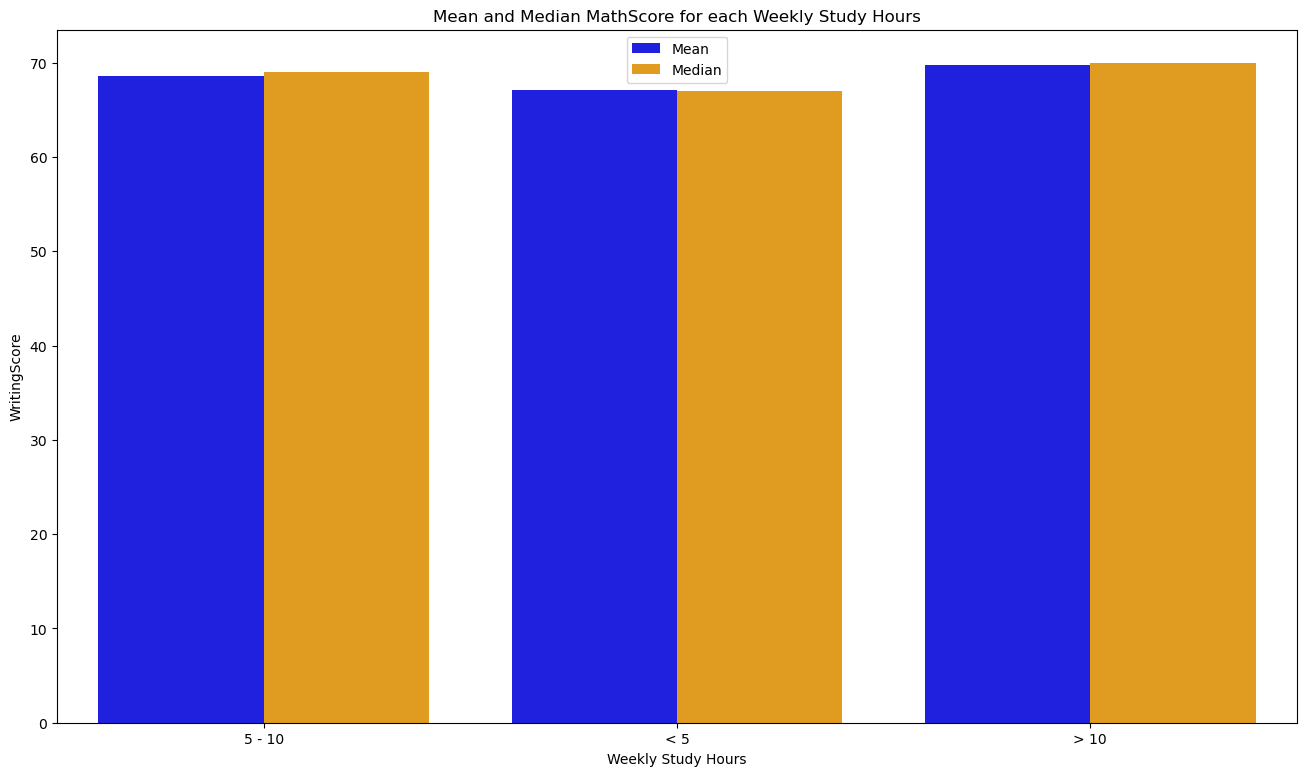

In [25]:
# Filter out missing values (NaN) in the 'WklyStudyHours' and 'WritingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['WklyStudyHours', 'WritingScore'])

# Calculate the mean MathScore for each category in WklyStudyHours
mean_scores = valid_data.groupby('WklyStudyHours')['WritingScore'].mean().reset_index()

# Calculate the median MathScore for each category in WklyStudyHours
median_scores = valid_data.groupby('WklyStudyHours')['WritingScore'].median().reset_index()

# Combine mean and median DataFrames into a single DataFrame
merged_scores = pd.concat([mean_scores.assign(Type='Mean'), median_scores.assign(Type='Median')])

# Create the unified bar plot to show mean and median for each category in WklyStudyHours
plt.figure(figsize=(16, 9))

# Plot the mean and median WritingScore as bars using the 'hue' parameter to distinguish them
sns.barplot(x='WklyStudyHours', y='WritingScore', hue='Type', data=merged_scores, palette=['blue', 'orange'])

# Customize the plot
plt.xlabel('Weekly Study Hours')
plt.ylabel('WritingScore')
plt.title('Mean and Median MathScore for each Weekly Study Hours')
plt.legend()

# Show the plot
plt.show()

Explanation:
The first thing we observe, there is a minor difference between the mean and median (we can infer the absent of extreme values) of Writing score across all Weekly Study Hours.
The second thing we observes, there is a minor difference between the values of mean and median of each group, Therefor the group has similar result of Writing score.
Given the plot we cannot infer any correlation between Weekly Study Hours and WritingScore of students.

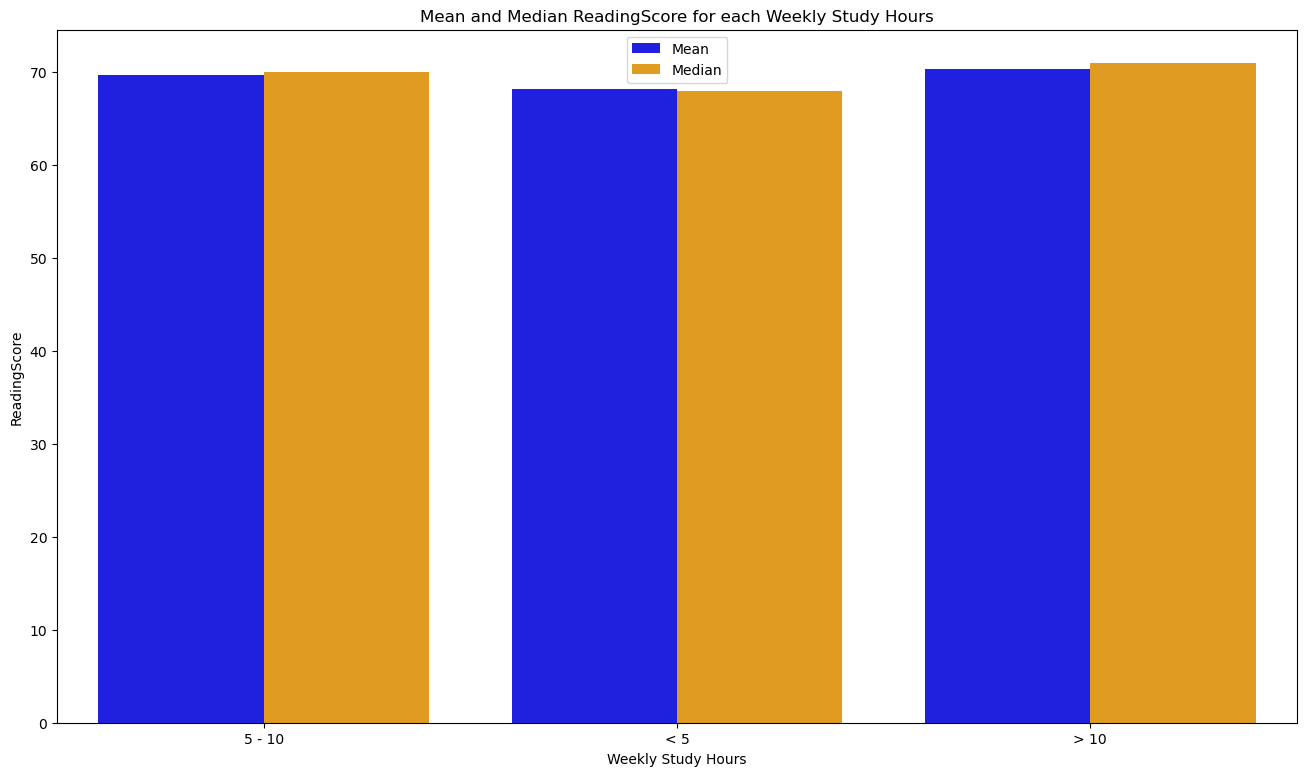

In [26]:
# Filter out missing values (NaN) in the 'WklyStudyHours' and 'ReadingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['WklyStudyHours', 'ReadingScore'])

# Calculate the mean MathScore for each category in WklyStudyHours
mean_scores = valid_data.groupby('WklyStudyHours')['ReadingScore'].mean().reset_index()

# Calculate the median MathScore for each category in WklyStudyHours
median_scores = valid_data.groupby('WklyStudyHours')['ReadingScore'].median().reset_index()

# Combine mean and median DataFrames into a single DataFrame
merged_scores = pd.concat([mean_scores.assign(Type='Mean'), median_scores.assign(Type='Median')])

# Create the unified bar plot to show mean and median for each category in WklyStudyHours
plt.figure(figsize=(16, 9))

# Plot the mean and median ReadingScore as bars using the 'hue' parameter to distinguish them
sns.barplot(x='WklyStudyHours', y='ReadingScore', hue='Type', data=merged_scores, palette=['blue', 'orange'])

# Customize the plot
plt.xlabel('Weekly Study Hours')
plt.ylabel('ReadingScore')
plt.title('Mean and Median ReadingScore for each Weekly Study Hours')
plt.legend()

# Show the plot
plt.show()

Explanation:
The first thing we observe, there is a minor difference between the mean and median (we can infer the absent of extreme values) of Reading score across all Weekly Study Hours.
The second thing we observes, there is a minor difference between the values of mean and median of each group, Therefor the group has similar result of Reading score.
Given the plot we cannot infer any correlation between Weekly Study Hours tendency and ReadingScore of students.

### PART 2 -Extended Exploratory Data Analysis <b>
We want to explore more possible connections / relations in the data 

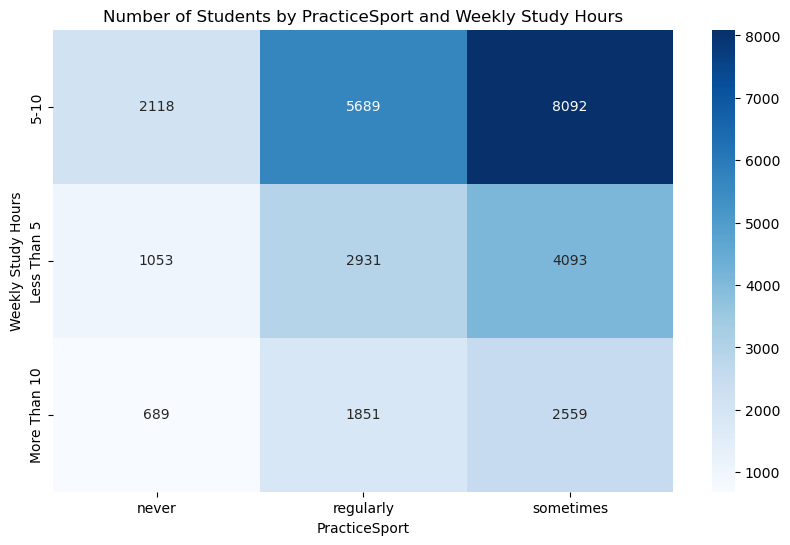

In [27]:
# Filter out missing values (NaN) in the 'PracticeSport' and 'WklyStudyHours' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'WklyStudyHours'])

# Create a cross-tabulation to count the number of students in each combination of categories
cross_tab = pd.crosstab(valid_data['WklyStudyHours'], valid_data['PracticeSport'])

# Define the custom labels for the y-axis
custom_labels = {'> 10': 'More Than 10', '5 - 10': '5-10', '< 5': 'Less Than 5'}

# Create the matrix plot graph using Seaborn's heatmap and apply custom labels
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="Blues", yticklabels=[custom_labels.get(label, label) for label in cross_tab.index])
plt.xlabel('PracticeSport')
plt.ylabel('Weekly Study Hours')
plt.title('Number of Students by PracticeSport and Weekly Study Hours')
plt.show()

Explanation:
We observed that the majority of students fall in to the category of : self study 5-10 hours a week and practice sports sometimes.

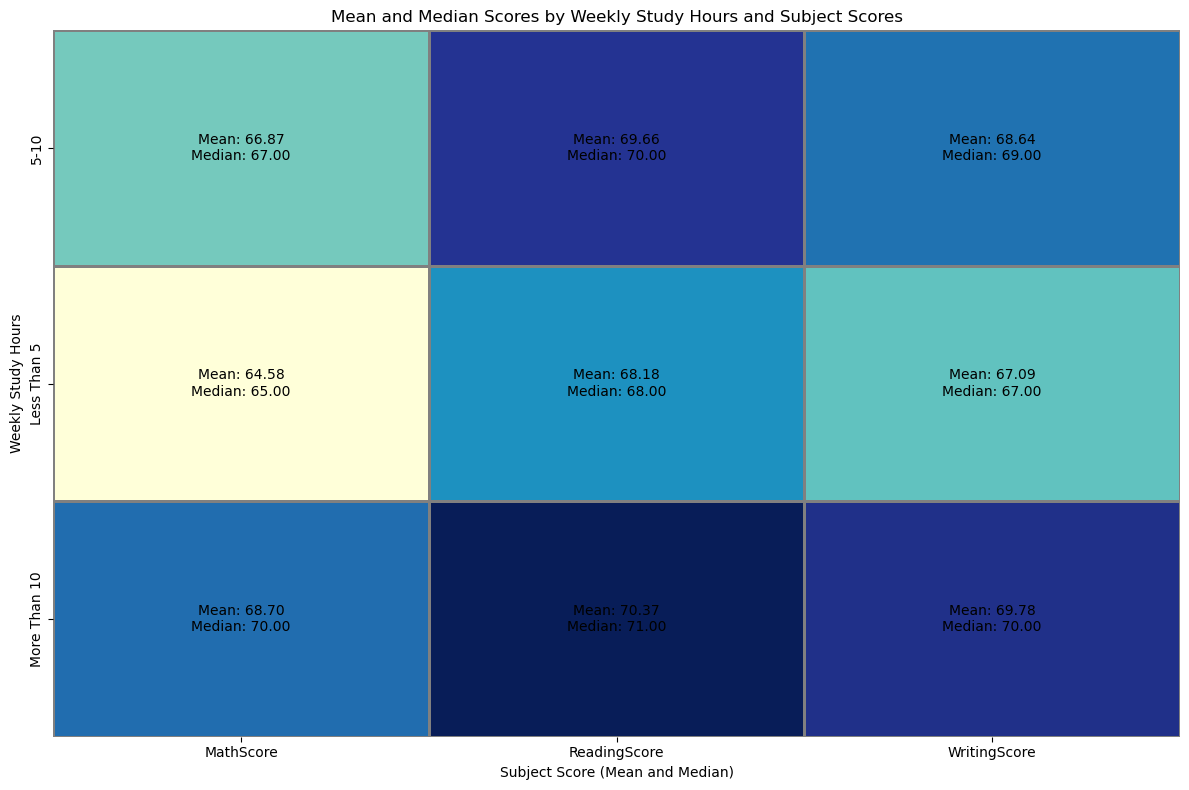

In [28]:
# Filter out missing values (NaN) in the 'WklyStudyHours', 'MathScore', 'ReadingScore', and 'WritingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['WklyStudyHours', 'MathScore', 'ReadingScore', 'WritingScore'])

# Create a pivot table to calculate the means and medians of each subject for each combination of 'WklyStudyHours'
pivot_table_stats = valid_data.pivot_table(index='WklyStudyHours', values=['MathScore', 'ReadingScore', 'WritingScore'],
                                          aggfunc=['mean', 'median'])

# Flatten the column index for the pivot table DataFrame
pivot_table_stats.columns = pivot_table_stats.columns.map('_'.join)

# Create custom labels for the y-axis
custom_labels = {'> 10': 'More Than 10', '5 - 10': '5-10', '< 5': 'Less Than 5'}

# Create the 3x3 matrix plot graph using Seaborn's heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(data=pivot_table_stats.iloc[:, :3], annot=False, fmt=".2f",
                 cmap="YlGnBu", cbar=False,
                 yticklabels=[custom_labels.get(label, label) for label in pivot_table_stats.index],
                 xticklabels=['MathScore', 'ReadingScore', 'WritingScore'],
                 linecolor='gray', linewidths=1)

# Add the combined mean and median text annotations using Matplotlib's text function
for i in range(len(pivot_table_stats)):
    for j in range(3):
        mean_value = pivot_table_stats.iloc[i, j]
        median_value = pivot_table_stats.iloc[i, j + 3]
        value = f"Mean: {mean_value:.2f}\nMedian: {median_value:.2f}"
        ax.text(j + 0.5, i + 0.5, value, ha='center', va='center', fontsize=10)

# Customize the plot
plt.xlabel('Subject Score (Mean and Median)')
plt.ylabel('Weekly Study Hours')
plt.title('Mean and Median Scores by Weekly Study Hours and Subject Scores')

plt.tight_layout()
plt.show()

Explanation:<br>
We observed the group that has more than 10 hours of self study a week achieves the highest score in average in all subjects.
We observed the group that has less than 5 hours of self study a week achieves the lowest score in average in all subjects.
Overall we observed that the difference in scores across all subjects between the highest and lowest self learning groups is around 3-5 points.

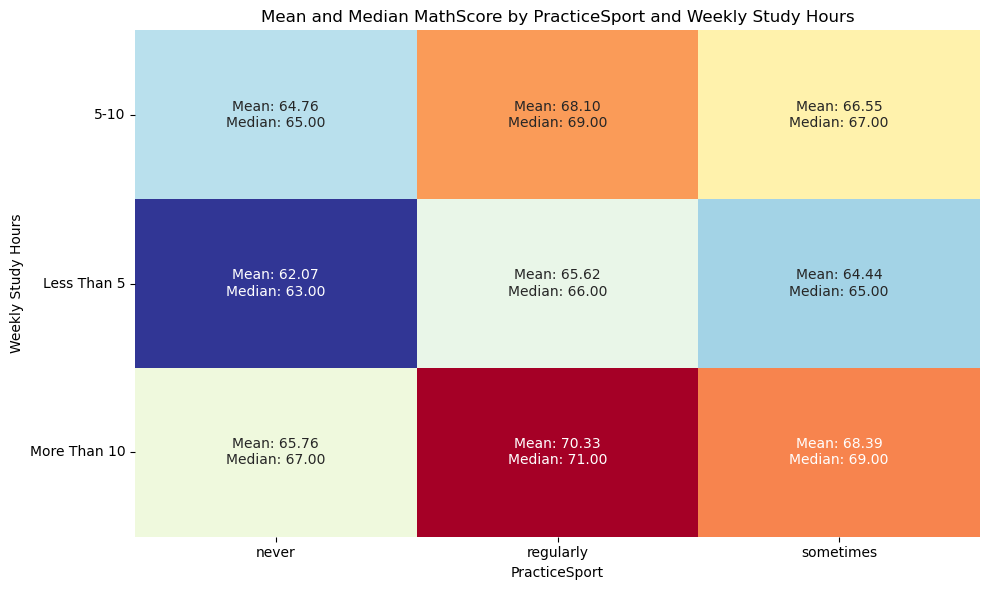

In [29]:
# Filter out missing values (NaN) in the 'PracticeSport', 'WklyStudyHours', and 'MathScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'WklyStudyHours', 'MathScore'])

# Calculate the mean MathScore for each combination of 'PracticeSport' and 'WklyStudyHours'
mean_scores = valid_data.groupby(['WklyStudyHours', 'PracticeSport'])['MathScore'].mean().reset_index()

# Pivot the mean_scores DataFrame to create a 3x3 matrix
mean_scores_pivot = mean_scores.pivot(index='WklyStudyHours', columns='PracticeSport', values='MathScore')

# Calculate the median MathScore for each combination of 'PracticeSport' and 'WklyStudyHours'
median_scores = valid_data.groupby(['WklyStudyHours', 'PracticeSport'])['MathScore'].median().reset_index()

# Pivot the median_scores DataFrame to create a 3x3 matrix
median_scores_pivot = median_scores.pivot(index='WklyStudyHours', columns='PracticeSport', values='MathScore')

# Combine mean and median values into a single DataFrame
combined_scores_pivot = pd.DataFrame(index=mean_scores_pivot.index, columns=mean_scores_pivot.columns)
for index, row in mean_scores_pivot.iterrows():
    for col in mean_scores_pivot.columns:
        mean_val = row[col]
        median_val = median_scores_pivot.loc[index, col]
        combined_scores_pivot.loc[index, col] = f"Mean: {mean_val:.2f}\nMedian: {median_val:.2f}"

# Create the custom labels for the y-axis
custom_labels = {'> 10': 'More Than 10', '5 - 10': '5-10', '< 5': 'Less Than 5'}

# Create the matrix plot graph using Seaborn's heatmap with the "RdYlBu" colormap
plt.figure(figsize=(10, 6))
sns.heatmap(mean_scores_pivot, annot=combined_scores_pivot, fmt="", cmap="RdYlBu_r", annot_kws={"fontsize": 10},
            cbar=False)

# Customize the plot
plt.xlabel('PracticeSport')
plt.ylabel('Weekly Study Hours')
plt.title('Mean and Median MathScore by PracticeSport and Weekly Study Hours')
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=[custom_labels.get(label, label) for label in combined_scores_pivot.index], rotation=0)

plt.tight_layout()
plt.show()

Explanation:<br>
We observed that the group that has the highest number of hours of self study a week is the group with the highest mean score in Math.
we observed that the sub-group of weekly study more than 10 hours and regularly practice sports is the sub-group with the highest score in Math in average.
We observed that the group that has the lowest number of hours of self study a week is the group with the lowest mean score in Math.
we observed that the sub-group of weekly study less than 5 hours and never practice sports is the sub-group with the lowest score in Math in average.

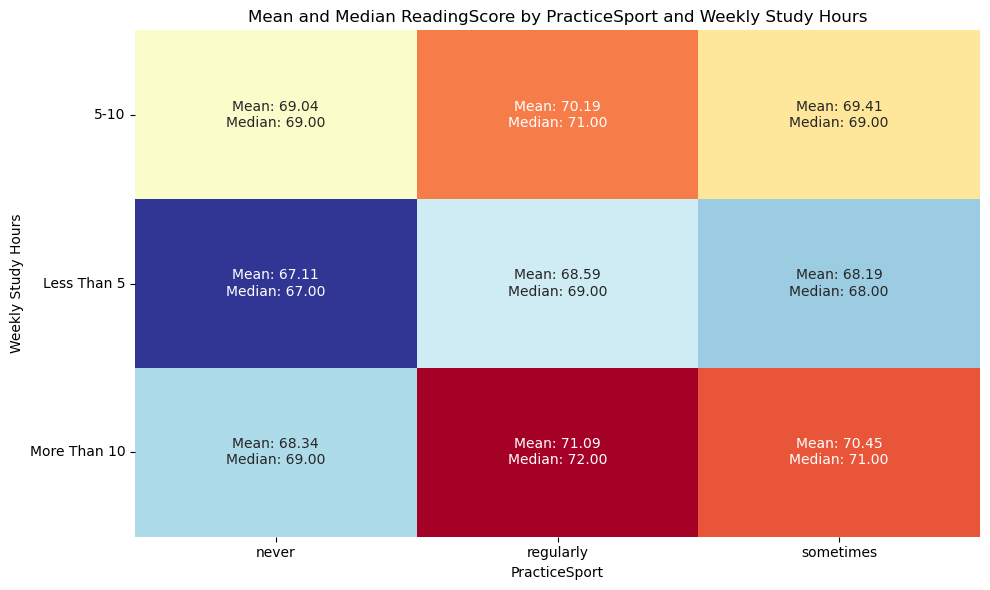

In [30]:
# Filter out missing values (NaN) in the 'PracticeSport', 'WklyStudyHours', and 'ReadingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'WklyStudyHours', 'ReadingScore'])

# Calculate the mean MathScore for each combination of 'PracticeSport' and 'WklyStudyHours'
mean_scores = valid_data.groupby(['WklyStudyHours', 'PracticeSport'])['ReadingScore'].mean().reset_index()

# Pivot the mean_scores DataFrame to create a 3x3 matrix
mean_scores_pivot = mean_scores.pivot(index='WklyStudyHours', columns='PracticeSport', values='ReadingScore')

# Calculate the median MathScore for each combination of 'PracticeSport' and 'WklyStudyHours'
median_scores = valid_data.groupby(['WklyStudyHours', 'PracticeSport'])['ReadingScore'].median().reset_index()

# Pivot the median_scores DataFrame to create a 3x3 matrix
median_scores_pivot = median_scores.pivot(index='WklyStudyHours', columns='PracticeSport', values='ReadingScore')

# Combine mean and median values into a single DataFrame
combined_scores_pivot = pd.DataFrame(index=mean_scores_pivot.index, columns=mean_scores_pivot.columns)
for index, row in mean_scores_pivot.iterrows():
    for col in mean_scores_pivot.columns:
        mean_val = row[col]
        median_val = median_scores_pivot.loc[index, col]
        combined_scores_pivot.loc[index, col] = f"Mean: {mean_val:.2f}\nMedian: {median_val:.2f}"

# Create the custom labels for the y-axis
custom_labels = {'> 10': 'More Than 10', '5 - 10': '5-10', '< 5': 'Less Than 5'}

# Create the matrix plot graph using Seaborn's heatmap with the "RdYlBu" colormap
plt.figure(figsize=(10, 6))
sns.heatmap(mean_scores_pivot, annot=combined_scores_pivot, fmt="", cmap="RdYlBu_r", annot_kws={"fontsize": 10},
            cbar=False)

# Customize the plot
plt.xlabel('PracticeSport')
plt.ylabel('Weekly Study Hours')
plt.title('Mean and Median ReadingScore by PracticeSport and Weekly Study Hours')
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=[custom_labels.get(label, label) for label in combined_scores_pivot.index], rotation=0)

plt.tight_layout()
plt.show()

Explanation:
We observed that the group that has the highest number of hours of self study a week is the group with the highest mean score in Reading.
we observed that the sub-group of weekly study more than 10 hours and regularly practice sports is the sub-group with the highest score in Reading in average.
We observed that the group that has the lowest number of hours of self study a week is the group with the lowest mean score in Reading.
we observed that the sub-group of weekly study less than 5 hours and never practice sports is the sub-group with the lowest score in Reading in average.

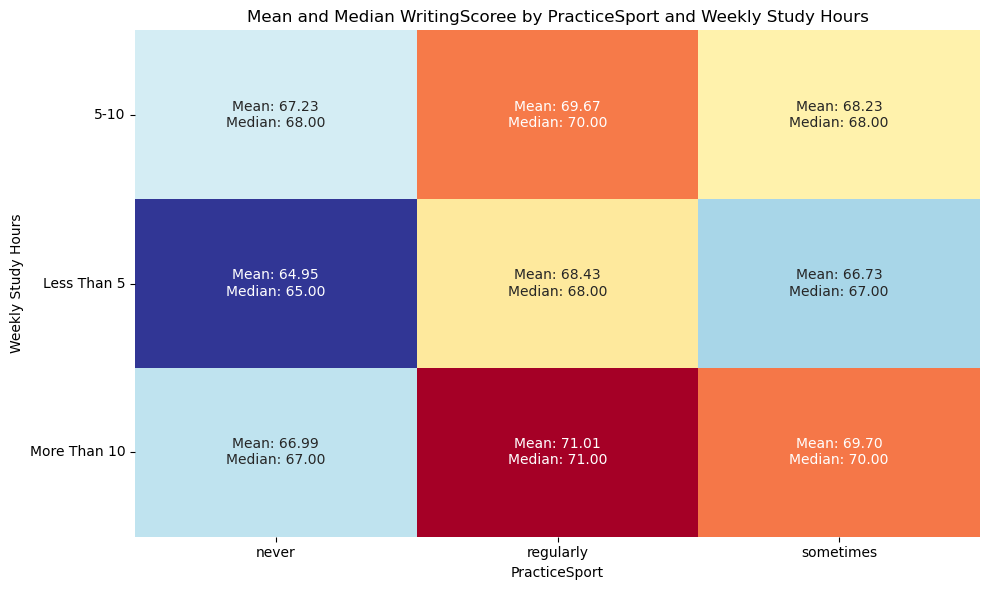

In [31]:
# Filter out missing values (NaN) in the 'PracticeSport', 'WklyStudyHours', and 'WritingScore' columns
valid_data = Students_Exam_Scores_df.dropna(subset=['PracticeSport', 'WklyStudyHours', 'WritingScore'])

# Calculate the mean MathScore for each combination of 'PracticeSport' and 'WklyStudyHours'
mean_scores = valid_data.groupby(['WklyStudyHours', 'PracticeSport'])['WritingScore'].mean().reset_index()

# Pivot the mean_scores DataFrame to create a 3x3 matrix
mean_scores_pivot = mean_scores.pivot(index='WklyStudyHours', columns='PracticeSport', values='WritingScore')

# Calculate the median MathScore for each combination of 'PracticeSport' and 'WklyStudyHours'
median_scores = valid_data.groupby(['WklyStudyHours', 'PracticeSport'])['WritingScore'].median().reset_index()

# Pivot the median_scores DataFrame to create a 3x3 matrix
median_scores_pivot = median_scores.pivot(index='WklyStudyHours', columns='PracticeSport', values='WritingScore')

# Combine mean and median values into a single DataFrame
combined_scores_pivot = pd.DataFrame(index=mean_scores_pivot.index, columns=mean_scores_pivot.columns)
for index, row in mean_scores_pivot.iterrows():
    for col in mean_scores_pivot.columns:
        mean_val = row[col]
        median_val = median_scores_pivot.loc[index, col]
        combined_scores_pivot.loc[index, col] = f"Mean: {mean_val:.2f}\nMedian: {median_val:.2f}"

# Create the custom labels for the y-axis
custom_labels = {'> 10': 'More Than 10', '5 - 10': '5-10', '< 5': 'Less Than 5'}

# Create the matrix plot graph using Seaborn's heatmap with the "RdYlBu" colormap
plt.figure(figsize=(10, 6))
sns.heatmap(mean_scores_pivot, annot=combined_scores_pivot, fmt="", cmap="RdYlBu_r", annot_kws={"fontsize": 10},
            cbar=False)

# Customize the plot
plt.xlabel('PracticeSport')
plt.ylabel('Weekly Study Hours')
plt.title('Mean and Median WritingScoree by PracticeSport and Weekly Study Hours')
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=[custom_labels.get(label, label) for label in combined_scores_pivot.index], rotation=0)

plt.tight_layout()
plt.show()

Explanation:
We observed that the group that has the highest number of hours of self study a week is the group with the highest mean score in Writing.
we observed that the sub-group of weekly study more than 10 hours and regularly practice sports is the sub-group with the highest score in Writing in average.
We observed that the group that has the lowest number of hours of self study a week is the group with the lowest mean score in Writing.
we observed that the sub-group of weekly study less than 5 hours and never practice sports is the sub-group with the lowest score in Writing in average.

Find the average score across all subject in the Data Set:

In [32]:
# Calculate the mean score for each subject
mean_math_score = Students_Exam_Scores_df['MathScore'].mean()
mean_reading_score = Students_Exam_Scores_df['ReadingScore'].mean()
mean_writing_score = Students_Exam_Scores_df['WritingScore'].mean()

# Calculate the overall mean score of all subjects
overall_mean_score = (mean_math_score + mean_reading_score + mean_writing_score) / 3

print("Mean Math Score:", mean_math_score)
print("Mean Reading Score:", mean_reading_score)
print("Mean Writing Score:", mean_writing_score)
print("Overall Mean Score of all subjects:", overall_mean_score)

Mean Math Score: 66.5584021409223
Mean Reading Score: 69.37753337032082
Mean Writing Score: 68.41862210763357
Overall Mean Score of all subjects: 68.1181858729589


### PART 3

1. The question we are interesting in to explore: How student achievements (score/grade) in Math, Writhing and Reading subjects changed as a function of the student tendency of practice sport.
The above question raise our interest for the reason that the relation between sport and study is a long live subject for debate and research, we are interested to see if there is a true side to the saying that practicing sports while studying can benefit in higher grades. 

## 2.Clearly state the two hypotheses
H0: The overall mean (Math, Writhing and Reading) score of students who practice sports is not significantly higher than the average overall mean score of all students.<br>
H1: The overall mean score of students who practice sports is significantly higher than the average overall mean score of all students.

## The test statistic:

A test statistic measures the degree of agreement between a sample of data and the null hypothesis. It contains information about the data that is relevant for deciding whether to reject the null hypothesis - in our case it's the <b> Overall mean calculated in the Expended exploratory data analyses part  - 68.11.

### Run a simulation and plot the parameter estimation under the null hypothesis. Also mark the test statistic.

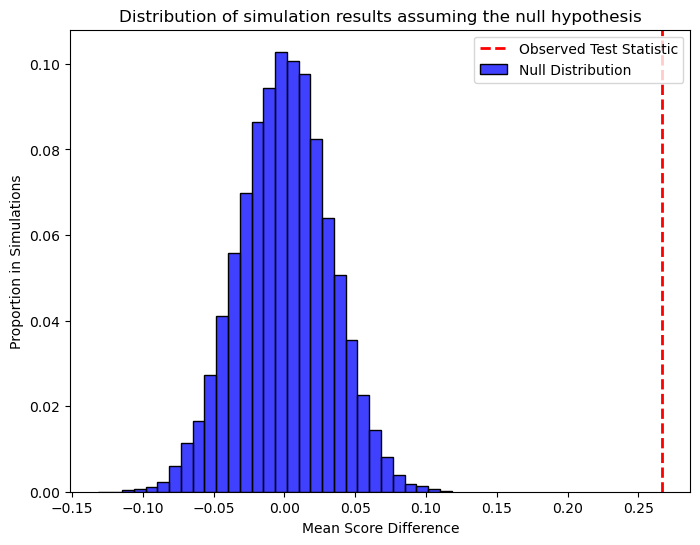

In [33]:
# Calculate the overall mean score of all subjects for each student
Students_Exam_Scores_df['OverallMeanScore'] = Students_Exam_Scores_df[['MathScore', 'ReadingScore', 'WritingScore']].mean(axis=1)

# Extract the scores of students who practice sports and those who do not
practice_sports_scores = Students_Exam_Scores_df[Students_Exam_Scores_df['PracticeSport'] != 'never']['OverallMeanScore']
no_practice_sports_scores = Students_Exam_Scores_df[Students_Exam_Scores_df['PracticeSport'] == 'never']['OverallMeanScore']

# Calculate the observed test statistic (mean score difference for the original data)
observed_test_statistic = np.mean(practice_sports_scores) - np.mean(Students_Exam_Scores_df['OverallMeanScore'])

# Number of simulations
num_simulations = 20000

# Simulate the null distribution
def simulate_null_distribution(num_simulations):
    null_distribution = []
    for _ in range(num_simulations):
        shuffled_scores = np.random.permutation(Students_Exam_Scores_df['OverallMeanScore'])
        shuffled_mean_score_diff = np.mean(shuffled_scores[Students_Exam_Scores_df['PracticeSport'] != 'never']) - np.mean(shuffled_scores)
        null_distribution.append(shuffled_mean_score_diff)
    return null_distribution

null_distribution = simulate_null_distribution(num_simulations)

# Plot the null distribution
plt.figure(figsize=(8, 6))
sns.histplot(null_distribution, bins=30, stat='probability', color='blue', edgecolor='black', label='Null Distribution')
plt.axvline(observed_test_statistic, color='red', linestyle='dashed', linewidth=2, label='Observed Test Statistic')
plt.xlabel('Mean Score Difference')
plt.ylabel('Proportion in Simulations')
plt.title('Distribution of simulation results assuming the null hypothesis')
plt.legend()
plt.show()

### What is the *p*-value of your test:

In [34]:
# Calculate the p-value
def calculate_p_value(observed_statistic, null_distribution):
    count_extreme = np.sum(np.abs(null_distribution) >= np.abs(observed_statistic))
    return count_extreme / len(null_distribution)

p_value = calculate_p_value(observed_test_statistic, null_distribution)
print("p-value:", p_value)

p-value: 0.0


### What is the conclusion:

We got $p_{value}<0.05$, which means that the observed case (the red dotted line) is part of the 5% tail of the empirical distribution. Therefore, assuming significance level of 0.05, we will reject the null hypothesis. That is, we can reject the hypothesis that overall mean (Math, Writhing and Reading) score of students who practice sports is not significantly higher than the average overall mean score of all students. It may be true that the overall mean score of students who practice sports is significantly higher than the average overall mean score of all students.

### PART 4

## What do you want to try to classify?
We want to try to classify the overall mean score in Math, Writhing and Reading of a student ('Mean').
## Why?
Given the ability to classify accurately score of a student base on parameter other then tests is a useful tool to have and can lead to interesting insights (e.g sports helps students get better grades, learning 5-10 hours a week can boost performance in test etc.).
## What is a potential application of an algorithm that classifies your target variable?
This model could have real-world applications in educational settings,where it could help identify factors that contribute to student performance and provide insights for targeted interventions to improve academic outcomes.

Target variable (class) - Overall mean score  
Using the features - Practice Sport frequency, Weekly self study hours, Gender, EthnicGroup, and ParentEduc  
We chose the above features as a result of the data exploration in PART 2. The graphs show that there is a relation between those features and the target class,indicating potential predictive power.<br>
Therefore, we aim to build a classification model that leverages this information to predict students' overall mean scores based on their practice sport frequency,<br>
weekly self-study hours, gender, ethnic group, and parental education.

## Data Preparation:
1. We will add to the data frame a column with the overall mean ('Mean') score for each student<br>
2. Then we will create a new data set with only 3 columns: 'PracticeSport' , 'WklyStudyHours' and 'Mean'<br>
3. Encoding categorical variables
4. After that we will find the percentage of each value (0/1/2) in each categorical fetcher replace randomly the null values to keep the same ration of (0/1/2) after the change.
5. Because the values of the fetchers are 0/1/2 scaling is not needed

In [8]:
# Select the desired columns from the original DataFrame
selected_columns = ['PracticeSport', 'WklyStudyHours', 'Gender', 'EthnicGroup', 'ParentEduc', 'Mean']
new_data = Students_Exam_Scores_df[selected_columns].copy()

# Encode PracticeSport and WklyStudyHours using specified mappings
practice_sport_mapping = {'never': 0, 'sometimes': 1, 'regularly': 2}
wkly_study_hours_mapping = {'< 5': 0, '5 - 10': 1, '> 10': 2}

new_data['PracticeSport'] = new_data['PracticeSport'].replace(practice_sport_mapping)
new_data['WklyStudyHours'] = new_data['WklyStudyHours'].replace(wkly_study_hours_mapping)

# Encode Gender using unit vector encoding
new_data['Gender'] = new_data['Gender'].map({'female': 1, 'male': 2})

# Create dictionaries for encoding EthnicGroup and ParentEduc
ethnic_group_mapping = {'group A': 1, 'group B': 2,
                        'group C': 3, 'group D': 4, 'group E': 5}

parent_educ_mapping = {'some high school': 1, 'high school': 2,
                       'some college': 3, "associate's degree": 4,
                       "bachelor's degree": 5, "master's degree": 6}

# Apply the mapping dictionaries to EthnicGroup and ParentEduc
new_data['EthnicGroup'] = new_data['EthnicGroup'].map(ethnic_group_mapping)
new_data['ParentEduc'] = new_data['ParentEduc'].map(parent_educ_mapping)

# Define a function to map Mean values
def map_mean(mean_value):
    if 0 <= mean_value < 50:
        return 1
    elif 50 <= mean_value < 61:
        return 2
    elif 61 <= mean_value < 81:
        return 3
    elif 81 <= mean_value < 96:
        return 4
    else:
        return 5

# Apply the mapping function to the 'Mean' column
new_data['Mean'] = new_data['Mean'].apply(map_mean)

# Calculate percentage of each value in each column
percentage_values = new_data.apply(lambda col: col.value_counts(normalize=True))

# Loop through each column and replace NaN values
for col in new_data.columns:
    if new_data[col].isnull().any():
        # Get available options for the column
        options = new_data[col].dropna().unique()
        # Calculate the number of NaN values
        num_null = new_data[col].isnull().sum()
        # Calculate percentages of available options
        option_percentages = percentage_values[col][options]
        # Generate random replacement values
        random_replacement = np.random.choice(options, size=num_null, p=option_percentages)
        # Replace NaN values
        new_data.loc[new_data[col].isnull(), col] = random_replacement

# Verify that there are no more NaN values in the DataFrame
display(new_data.head())

,PracticeSport,WklyStudyHours,Gender,EthnicGroup,ParentEduc,Mean
0,2.0,0.0,1,3.0,5.0,3
1,1.0,1.0,1,3.0,3.0,4
2,1.0,0.0,1,2.0,6.0,4
3,0.0,1.0,2,1.0,4.0,1
4,1.0,1.0,2,3.0,3.0,3


In [13]:
from sklearn.model_selection import train_test_split

# Separate the target variable 'Mean' from the features
X = new_data[['PracticeSport', 'WklyStudyHours', 'Gender', 'EthnicGroup', 'ParentEduc']]
y_mean = new_data['Mean']

# Create a binary target variable 'HighMean'
y_high_mean = y_mean.apply(lambda x: 1 if x >= 4 else 0)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_high_mean, test_size=0.2, random_state=42)

# Display the shapes of the resulting train and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24512, 5)
X_test shape: (6129, 5)
y_train shape: (24512,)
y_test shape: (6129,)


## Run 10-fold CV to find optimal k - using only the training data

Highest accuracy is obtained for k = 22 and equals 0.7932442263137263


Text(0, 0.5, 'Accuracy')

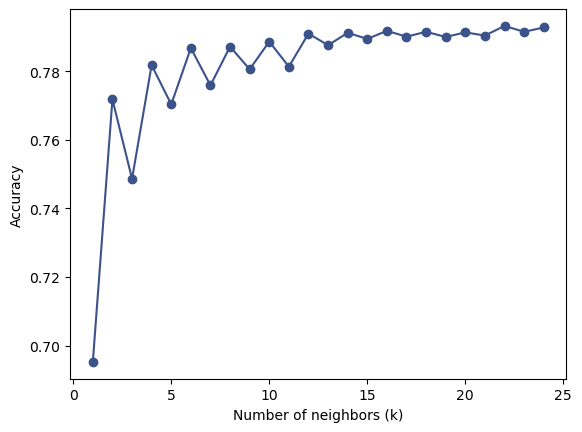

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

mean_cv_scores = []
k_list = range(1, 25)
for nn in k_list:
    knn_cv = KNeighborsClassifier(n_neighbors=nn)
    cv_scores = cross_val_score(knn_cv, X_train, y_train, cv=10)
    mean_cv_scores.append(cv_scores.mean())

# output results
best_k = mean_cv_scores.index(max(mean_cv_scores)) + 1
print('Highest accuracy is obtained for k =', best_k, 'and equals', max(mean_cv_scores))
plt.plot(k_list, mean_cv_scores, '-o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Accuracy')

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Create the KNN classifier with the optimal k value
knn_classifier = KNeighborsClassifier(n_neighbors=best_k)

# Fit the classifier on the training data
knn_classifier.fit(X_train, y_train)

# Calculate the accuracy on the test data
accuracy = knn_classifier.score(X_test, y_test)
print('Accuracy of the classifier is:', accuracy)

# Compute a confusion matrix
predictions = knn_classifier.predict(X=X_test)
conf_matrix = confusion_matrix(y_true=y_test, y_pred=predictions)
print('Confusion matrix:\n', conf_matrix)

# Calculate precision and recall
precision = precision_score(y_true=y_test, y_pred=predictions, average='macro')
recall = recall_score(y_true=y_test, y_pred=predictions, average='macro')

print('Precision:', precision)
print('Recall:', recall)

Accuracy of the classifier is: 0.7983357807146353
Confusion matrix:
 [[4867   33]
 [1203   26]]
Precision: 0.621245078602742
Recall: 0.5072103585128112
